In [1]:
import pandas as pd 
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
data = pd.read_parquet("/Users/joulesss/Documents/CV/Technical Tests JOBS/Prueba Tecnica MLEng 3/coffee_db.parquet")
data

,Country,Coffee type,1990/91,1991/92,1992/93,1993/94,1994/95,1995/96,1996/97,1997/98,...,2011/12,2012/13,2013/14,2014/15,2015/16,2016/17,2017/18,2018/19,2019/20,Total_domestic_consumption
0,Angola,Robusta/Arabica,1200000,1800000,2100000,1200000,1500000,600000,1200000,2400000,...,1800000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,1800000,46500000
1,Bolivia (Plurinational State of),Arabica,1500000,1620000,1650000,1710000,1770000,1830000,1890000,1950000,...,2940000,3030000,3120000,3210000,3300000,3420000,3510000,3600000,3660000,75180000
2,Brazil,Arabica/Robusta,492000000,510000000,534000000,546000000,558000000,606000000,660000000,690000000,...,1183200000,1219800000,1205100000,1219980000,1230480000,1273500000,1319820000,1332000000,1320000000,27824700000
3,Burundi,Arabica/Robusta,120000,96000,102000,114600,120000,120000,120000,120000,...,120000,120000,120000,120000,120000,120000,120000,120000,120000,3412020
4,Ecuador,Arabica/Robusta,21000000,21000000,21000000,21000000,21000000,21000000,18000000,18000000,...,9000000,9000000,9300000,9300000,9300000,9300000,9300000,9300000,8940000,381540000
5,Indonesia,Robusta/Arabica,74520000,76800000,79140000,81540000,84000000,86580000,89160000,91920000,...,220020000,234000000,255000000,265020000,273000000,279000000,285000000,288000000,288360000,4920480000
6,Madagascar,Robusta,21000000,18000000,21000000,21600000,9999960,10020000,10020000,10020000,...,27000000,25800000,24600000,23400000,22200000,21600000,21900000,22500000,22500000,588705960
7,Malawi,Arabica,120000,120000,120000,120000,120000,120000,120000,120000,...,60000,60000,60000,60000,60000,60000,60000,60000,60000,2340000
8,Papua New Guinea,Arabica/Robusta,180000,180000,180000,120000,120000,120000,120000,120000,...,74160,102660,122340,115440,108000,120000,120000,120000,120000,3608400
9,Paraguay,Arabica,900000,900000,900000,1200000,1200000,1200000,1200000,1200000,...,1200000,1200000,1200000,1200000,1200000,1200000,1200000,1200000,1200000,35100000


In [3]:
data["Coffee type"].value_counts()

Coffee type
Arabica            22
Robusta            15
Robusta/Arabica    10
Arabica/Robusta     8
Name: count, dtype: int64

In [4]:
data = data.rename(columns={
      "Country": "country",
      "Coffee type": "coffee_type",
      "Total_domestic_consumption": "total_domestic_consumption"
  })

year_cols = [c for c in data.columns if re.fullmatch(r"\d{4}/\d{2}", str(c))]

coffee_long = data.melt(
      id_vars=["country", "coffee_type", "total_domestic_consumption"],
      value_vars=year_cols,
      var_name="season",
      value_name="consumption"
  )

coffee_long["start_year"] = coffee_long["season"].str[:4].astype(int)
coffee_long["consumption"] = pd.to_numeric(coffee_long["consumption"],
errors="coerce")

coffee_long.head()


,country,coffee_type,total_domestic_consumption,season,consumption,start_year
0,Angola,Robusta/Arabica,46500000,1990/91,1200000,1990
1,Bolivia (Plurinational State of),Arabica,75180000,1990/91,1500000,1990
2,Brazil,Arabica/Robusta,27824700000,1990/91,492000000,1990
3,Burundi,Arabica/Robusta,3412020,1990/91,120000,1990
4,Ecuador,Arabica/Robusta,381540000,1990/91,21000000,1990


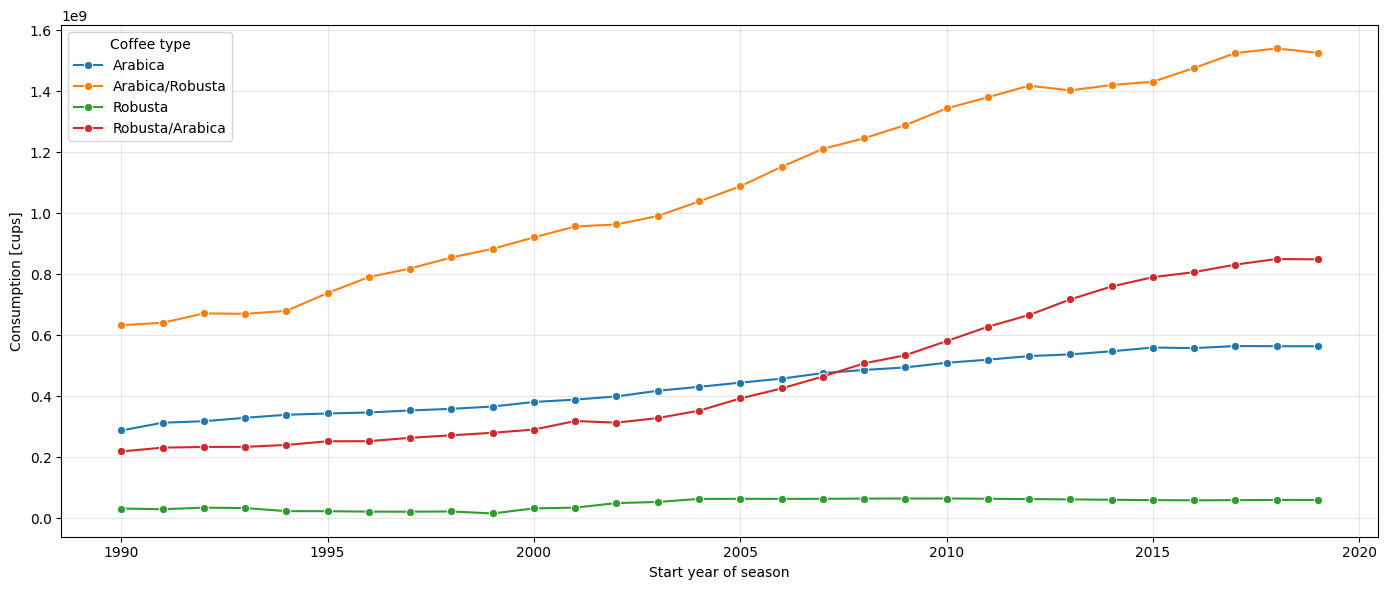

In [5]:
type_year = (
      coffee_long
      .groupby(["start_year", "season", "coffee_type"], as_index=False)
      ["consumption"]
      .sum()
  )

plt.figure(figsize=(14, 6))
sns.lineplot(
      data=type_year,
      x="start_year",
      y="consumption",
      hue="coffee_type",
      marker="o"
  )
#plt.title("Coffee Consumption by Type Across Years")
plt.xlabel("Start year of season")
plt.ylabel("Consumption [cups]")
plt.grid(alpha=0.3)
plt.legend(title="Coffee type")
plt.tight_layout()
plt.show()


In [ ]:
info_country_data = coffee_long["country"].value_counts()
print(info_country_data[info_country_data != 30].index.tolist())


[]


In [7]:
country_map = {
      "Bolivia (Plurinational State of)": "Bolivia",
      "Congo": "Republic of the Congo",
      "Democratic Republic of Congo": "Democratic Republic of the Congo",
      "Lao People's Democratic Republic": "Laos",
      "Timor-Leste": "East Timor",
      "Viet Nam": "Vietnam",
      "Trinidad & Tobago": "Trinidad and Tobago"
  }

coffee_long["country_plot"] = coffee_long["country"].replace(country_map)

  # Aggregate by country and season

map_df = (
      coffee_long
      .groupby(["season", "start_year", "country_plot"], as_index=False)
      ["consumption"]
      .sum()
  )

map_df.head()

  

fig = px.scatter_geo(
      map_df,
      locations="country_plot",
      locationmode="country names",
      size="consumption",
      color="consumption",
      hover_name="country_plot",
      animation_frame="season",
      projection="natural earth",
      size_max=45,
      color_continuous_scale="RdYlGn",
      title="Coffee Consumption by Country Over Time"
  )

fig.update_layout(
      margin=dict(l=0, r=0, t=50, b=0),
      geo=dict(
          showframe=False,
          showcoastlines=True,
          showcountries=True,
          countrycolor="lightgray"
      )
  )

fig.show()



/var/folders/ky/yhp0lcj54m54hstf278ctj8m0000gn/T/ipykernel_14339/947754311.py:26: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.scatter_geo(


In [8]:

map_type_df = (
      coffee_long
      .groupby(["season", "start_year", "country_plot", "coffee_type"],
      as_index=False)["consumption"]
      .sum()
  )

fig = px.scatter_geo(
      map_type_df,
      locations="country_plot",
      locationmode="country names",
      size="consumption",
      color="coffee_type",
      hover_name="country_plot",
      hover_data={"consumption": ":,.0f", "season": True, "coffee_type": True},
      animation_frame="season",
      projection="natural earth",
      size_max=40,
      title="Coffee Consumption by Country and Coffee Type"
  )

fig.update_layout(
      margin=dict(l=0, r=0, t=50, b=0),
      geo=dict(
          showframe=False,
          showcoastlines=True,
          showcountries=True
      )
  )

fig.show()

/var/folders/ky/yhp0lcj54m54hstf278ctj8m0000gn/T/ipykernel_14339/1268211930.py:8: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.



In [9]:
selected_type = "Arabica"  # change to Robusta, Arabica + Robusta, etc.

map_type_df = (
      coffee_long[coffee_long["coffee_type"] == selected_type]
      .groupby(["season", "start_year", "country_plot"], as_index=False)
      ["consumption"]
      .sum()
  )

fig = px.choropleth(
      map_type_df,
      locations="country_plot",
      locationmode="country names",
      color="consumption",
      hover_name="country_plot",
      animation_frame="season",
      color_continuous_scale="Blues",
      title=f"{selected_type} Consumption by Country Over Time"
  )

fig.update_layout(
      geo=dict(showframe=False, showcoastlines=True),
      margin=dict(l=0, r=0, t=50, b=0)
  )

fig.show()

/var/folders/ky/yhp0lcj54m54hstf278ctj8m0000gn/T/ipykernel_14339/3629945686.py:10: DeprecationWarning:

The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.

